# Project 8: Urban Bike-Sharing Demand Prediction with Graph Learning

**Team Members:** *Shivya Dahiya, Sanaullah, Viswa Sai Mandava, Rahul Sheoran*

*Bike-sharing systems play an important role in urban transportation by providing a flexible and eco-friendly mode of travel. However, maintaining a balance between bike availability and empty docks across stations is a major operational challenge. Stations that frequently become empty or full can negatively impact user experience. This project analyzes the Melbourne Bike Share dataset to understand station usage patterns and identify demand fluctuations across different times and locations. The analysis focuses on detecting high-pressure stations and peak usage periods. In addition, a machine learning model is developed to predict bike availability using historical data. The goal is to demonstrate how data analysis and predictive modeling can support better decision-making in urban mobility systems.*

**Import Libraries**

In [1]:
# import section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

**Load the dataset** 
*The Melbourne Bike Share Station Readings 2011-2017 dataset is loaded into a Pandas DataFrame for analysis. Initial inspection of the data is performed to understand its structure, including the number of rows, columns, and overall format.*

In [3]:
# load the dataset
df = pd.read_csv("bike_sharing.csv")
df.head()

,ID,NAME,TERMINALNAME,NBBIKES,NBEMPTYDOCKS,RUNDATE,INSTALLED,TEMPORARY,LOCKED,LASTCOMMWITHSERVER,LATESTUPDATETIME,REMOVALDATE,INSTALLDATE,LAT,LONG,LOCATION
0,2,Harbour Town - Docklands Dve - Docklands,60000,10,11,20170422134506,True,False,False,1492832566010,1.492833e+12,NaN,1.313725e+12,-37.814022,144.939521,"(-37.814022, 144.939521)"
1,4,Federation Square - Flinders St / Swanston St ...,60001,9,18,20170422134506,True,False,False,1492832631727,1.492832e+12,NaN,NaN,-37.817523,144.967814,"(-37.817523, 144.967814)"
2,6,State Library - Swanston St / Little Lonsdale ...,60003,1,10,20170422134506,True,False,False,1492832015231,1.492832e+12,NaN,NaN,-37.810702,144.964417,"(-37.810702, 144.964417)"
3,7,Bourke Street Mall - 205 Bourke St - City,60004,4,7,20170422134506,True,False,False,1492832218661,1.492830e+12,NaN,NaN,-37.813088,144.967437,"(-37.813088, 144.967437)"
4,8,Melbourne Uni - Tin Alley - Carlton,60005,8,11,20170422134506,True,False,False,1492832103674,1.492769e+12,NaN,NaN,-37.796250,144.960858,"(-37.79625, 144.960858)"


In [7]:
# check shape and columns
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

Shape of dataset: (5644554, 16)

Columns:
 Index(['ID', 'NAME', 'TERMINALNAME', 'NBBIKES', 'NBEMPTYDOCKS', 'RUNDATE',
       'INSTALLED', 'TEMPORARY', 'LOCKED', 'LASTCOMMWITHSERVER',
       'LATESTUPDATETIME', 'REMOVALDATE', 'INSTALLDATE', 'LAT', 'LONG',
       'LOCATION'],
      dtype='object')


In [10]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5644554 entries, 0 to 5644553
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ID                  int64  
 1   NAME                object 
 2   TERMINALNAME        int64  
 3   NBBIKES             int64  
 4   NBEMPTYDOCKS        int64  
 5   RUNDATE             int64  
 6   INSTALLED           bool   
 7   TEMPORARY           bool   
 8   LOCKED              bool   
 9   LASTCOMMWITHSERVER  int64  
 10  LATESTUPDATETIME    float64
 11  REMOVALDATE         float64
 12  INSTALLDATE         float64
 13  LAT                 float64
 14  LONG                float64
 15  LOCATION            object 
dtypes: bool(3), float64(5), int64(6), object(2)
memory usage: 576.0+ MB


**Data Cleaning**
*Data cleaning is performed to ensure the dataset is accurate and reliable. Duplicate records are removed, missing values in important columns are handled, and only active and valid stations are retained. This step is crucial for improving the quality of analysis and model performance.*

In [11]:
# check missing values
df.isnull().sum()

ID                          0
NAME                        0
TERMINALNAME                0
NBBIKES                     0
NBEMPTYDOCKS                0
RUNDATE                     0
INSTALLED                   0
TEMPORARY                   0
LOCKED                      0
LASTCOMMWITHSERVER          0
LATESTUPDATETIME         1225
REMOVALDATE           5644554
INSTALLDATE           1242587
LAT                         0
LONG                        0
LOCATION                    0
dtype: int64

In [12]:
# check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 65


In [13]:
# remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5644489, 16)


In [15]:
# keeping only useful rows
df = df[df["INSTALLED"] == True]
df = df[df["LOCKED"] == False]
df = df[df["TEMPORARY"] == False]

In [16]:
# drop rows missing important fields
df = df.dropna(subset=["NAME", "NBBIKES", "NBEMPTYDOCKS", "LAT", "LONG"])

**Feature Engineering**
*New features are created to enhance the dataset and make it more suitable for analysis. This includes calculating total dock capacity, bike availability ratios, and classifying stations based on their operational pressure. These features help in better understanding usage patterns and improving model performance.*

In [17]:
# create total dock capacity
df["TOTAL_DOCKS"] = df["NBBIKES"] + df["NBEMPTYDOCKS"]

In [18]:
# remove rows where total docks is zero
df = df[df["TOTAL_DOCKS"]>0]

In [19]:
# check after cleaning
print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (5624654, 17)


,ID,NAME,TERMINALNAME,NBBIKES,NBEMPTYDOCKS,RUNDATE,INSTALLED,TEMPORARY,LOCKED,LASTCOMMWITHSERVER,LATESTUPDATETIME,REMOVALDATE,INSTALLDATE,LAT,LONG,LOCATION,TOTAL_DOCKS
0,2,Harbour Town - Docklands Dve - Docklands,60000,10,11,20170422134506,True,False,False,1492832566010,1.492833e+12,NaN,1.313725e+12,-37.814022,144.939521,"(-37.814022, 144.939521)",21
1,4,Federation Square - Flinders St / Swanston St ...,60001,9,18,20170422134506,True,False,False,1492832631727,1.492832e+12,NaN,NaN,-37.817523,144.967814,"(-37.817523, 144.967814)",27
2,6,State Library - Swanston St / Little Lonsdale ...,60003,1,10,20170422134506,True,False,False,1492832015231,1.492832e+12,NaN,NaN,-37.810702,144.964417,"(-37.810702, 144.964417)",11
3,7,Bourke Street Mall - 205 Bourke St - City,60004,4,7,20170422134506,True,False,False,1492832218661,1.492830e+12,NaN,NaN,-37.813088,144.967437,"(-37.813088, 144.967437)",11
4,8,Melbourne Uni - Tin Alley - Carlton,60005,8,11,20170422134506,True,False,False,1492832103674,1.492769e+12,NaN,NaN,-37.796250,144.960858,"(-37.79625, 144.960858)",19


**Time-based Feature Creation**
*Datetime information is processed to extract useful components such as hour, day, and month. These features allow analysis of temporal patterns, such as peak hours and day-wise trends in bike availability.*

In [23]:
# check time related columns
df[["RUNDATE", "LATESTUPDATETIME", "INSTALLDATE"]].head(10)

df["RUNDATE"] = pd.to_datetime(df["RUNDATE"], errors = "coerce")
print("Missing RUNDATE after conversion:", df["RUNDATE"].isnull().sum())

df["LATESTUPDATETIME"] = pd.to_datetime(df["LATESTUPDATETIME"], errors="coerce")
print("Missing LATESTUPDATETIME after conversion:", df["LATESTUPDATETIME"].isnull().sum())

Missing RUNDATE after conversion: 0
Missing LATESTUPDATETIME after conversion: 0


In [26]:
# create time based features
df["datetime"] = df["RUNDATE"]
df = df.dropna(subset=["datetime"])

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()

**Add new features**

In [28]:
# bike ratio and empty ratio
df["bike_ratio"] = df["NBBIKES"] / df["TOTAL_DOCKS"]
df["empty_ratio"] = df["NBEMPTYDOCKS"] / df["TOTAL_DOCKS"]

# pressure status
df["pressure_status"] = np.where(
    df["bike_ratio"] <= 0.2, "Nearly Empty",
    np.where(df["bike_ratio"] >= 0.8, "Nearly Full", "Balanced")
)

# check new columns
df[["NAME", "NBBIKES", "NBEMPTYDOCKS", "TOTAL_DOCKS", "bike_ratio", "pressure_status", "hour", "day_of_week"]].head()

,NAME,NBBIKES,NBEMPTYDOCKS,TOTAL_DOCKS,bike_ratio,pressure_status,hour,day_of_week
0,Harbour Town - Docklands Dve - Docklands,10,11,21,0.476190,Balanced,5,Thursday
1,Federation Square - Flinders St / Swanston St ...,9,18,27,0.333333,Balanced,5,Thursday
2,State Library - Swanston St / Little Lonsdale ...,1,10,11,0.090909,Nearly Empty,5,Thursday
3,Bourke Street Mall - 205 Bourke St - City,4,7,11,0.363636,Balanced,5,Thursday
4,Melbourne Uni - Tin Alley - Carlton,8,11,19,0.421053,Balanced,5,Thursday


**Save the clean dataset**

In [29]:
# save cleaned dataset
df.to_csv("bike_sharing_clean.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


**Exploratory Data Analysis (EDA) and Visualisations**
*Exploratory Data Analysis is performed to identify patterns, trends, and relationships in the data. Visualizations are used to analyze station usage, bike availability over time, and distribution of operational pressure across stations.*

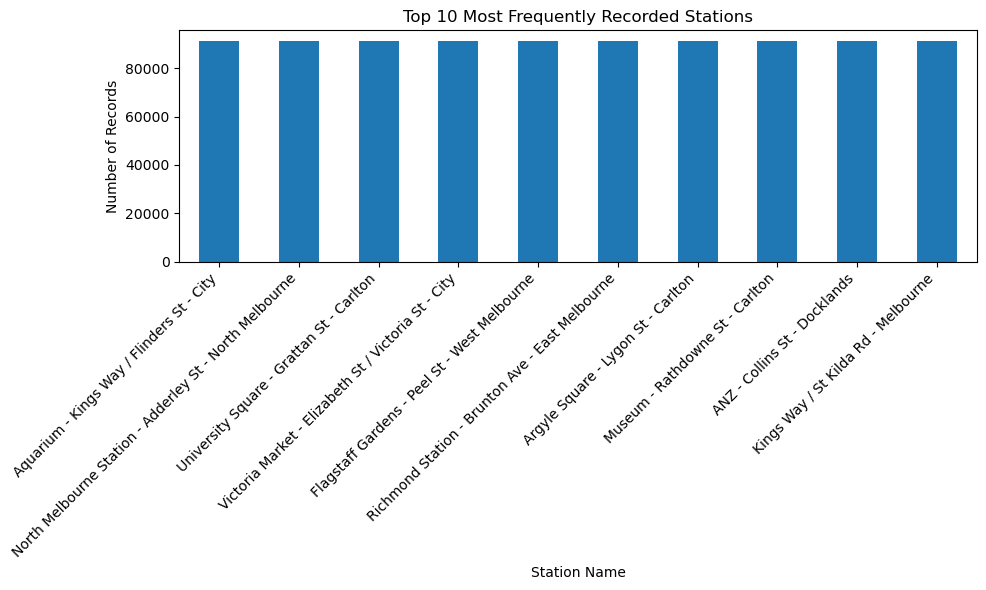

In [30]:
# top 10 most frequently recorded stations
top_stations = df["NAME"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_stations.plot(kind="bar")
plt.title("Top 10 Most Frequently Recorded Stations")
plt.xlabel("Station Name")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

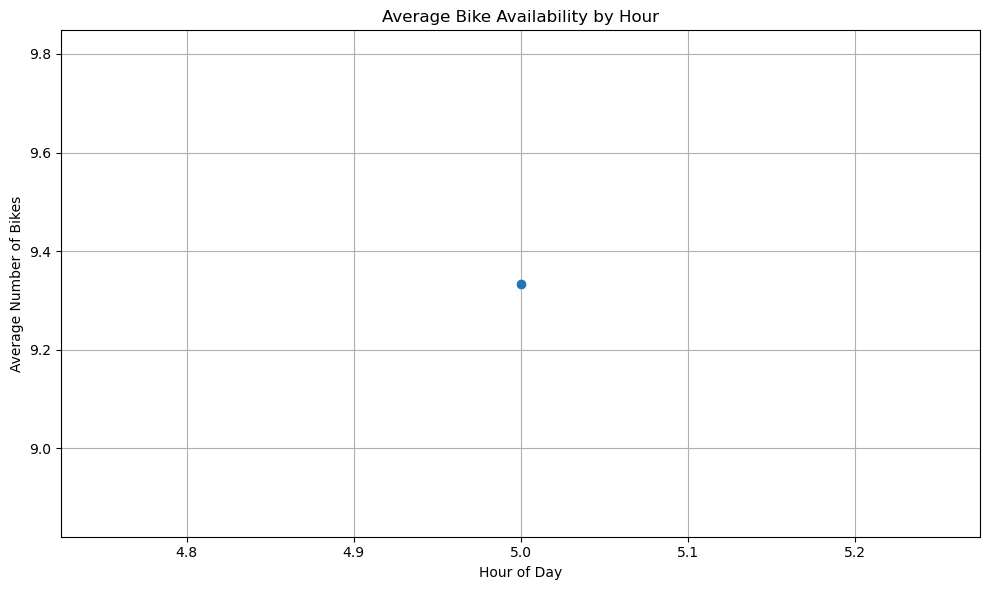

In [31]:
# average bike availability by hour
hourly_bikes = df.groupby("hour")["NBBIKES"].mean()

plt.figure(figsize=(10, 6))
plt.plot(hourly_bikes.index, hourly_bikes.values, marker="o")
plt.title("Average Bike Availability by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Bikes")
plt.grid(True)
plt.tight_layout()
plt.show()

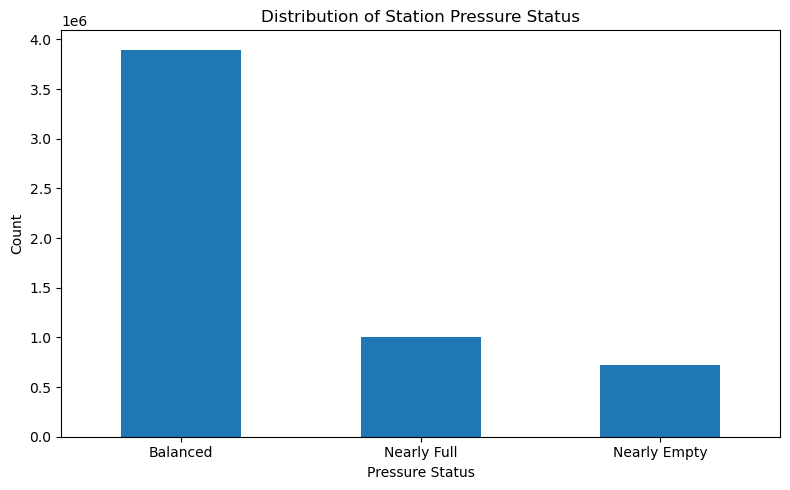

In [32]:
# pressure status distribution
pressure_counts = df["pressure_status"].value_counts()

plt.figure(figsize=(8, 5))
pressure_counts.plot(kind="bar")
plt.title("Distribution of Station Pressure Status")
plt.xlabel("Pressure Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

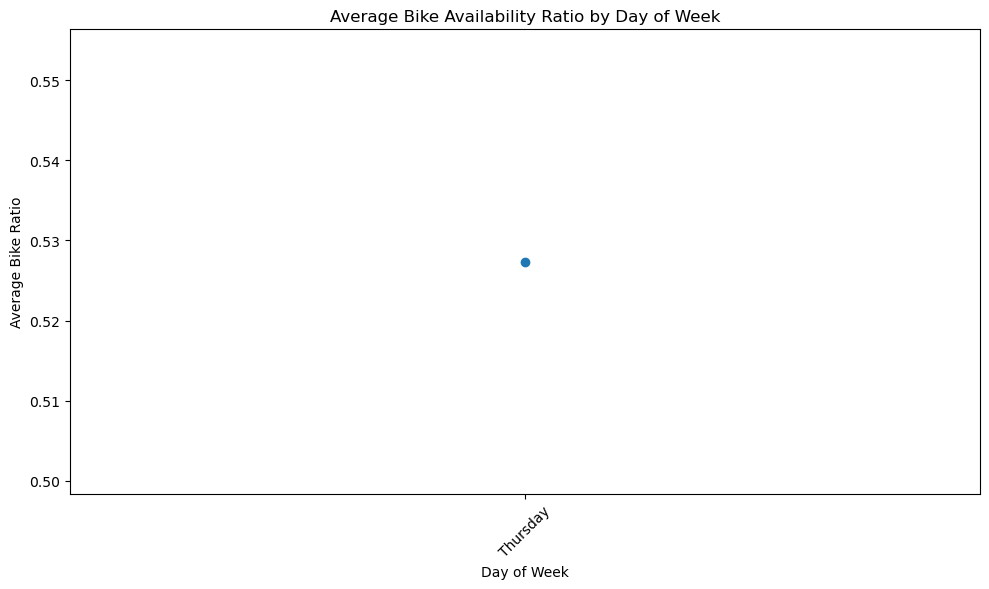

In [33]:
# average bike ratio by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_ratio = df.groupby("day_of_week")["bike_ratio"].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
plt.plot(day_ratio.index, day_ratio.values, marker="o")
plt.title("Average Bike Availability Ratio by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Bike Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

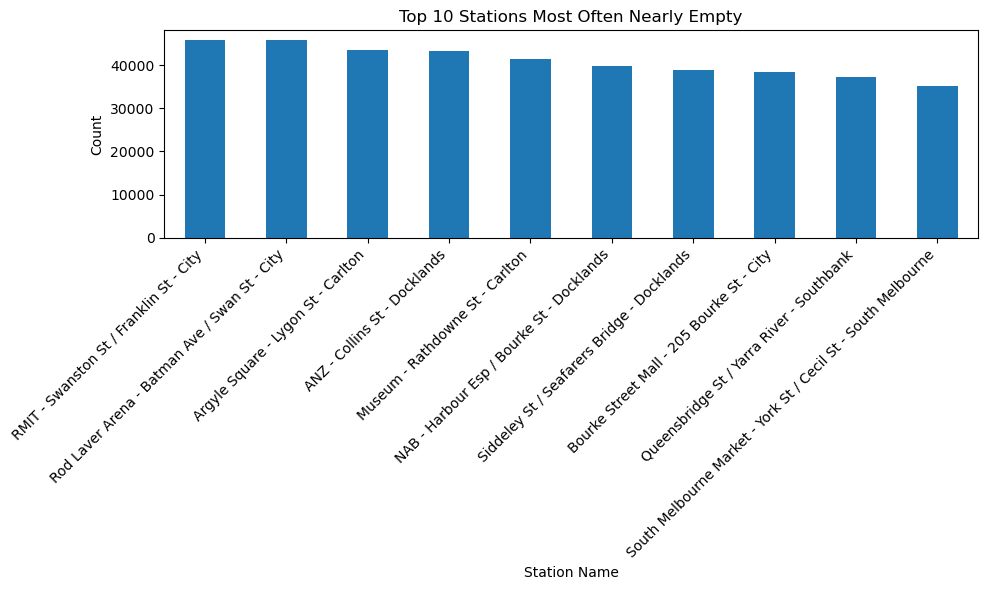

In [34]:
# top 10 stations most oftene nearly empty
nearly_empty = df[df["pressure_status"] == "Nearly Empty"]["NAME"].value_counts().head(10)

plt.figure(figsize=(10, 6))
nearly_empty.plot(kind="bar")
plt.title("Top 10 Stations Most Often Nearly Empty")
plt.xlabel("Station Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

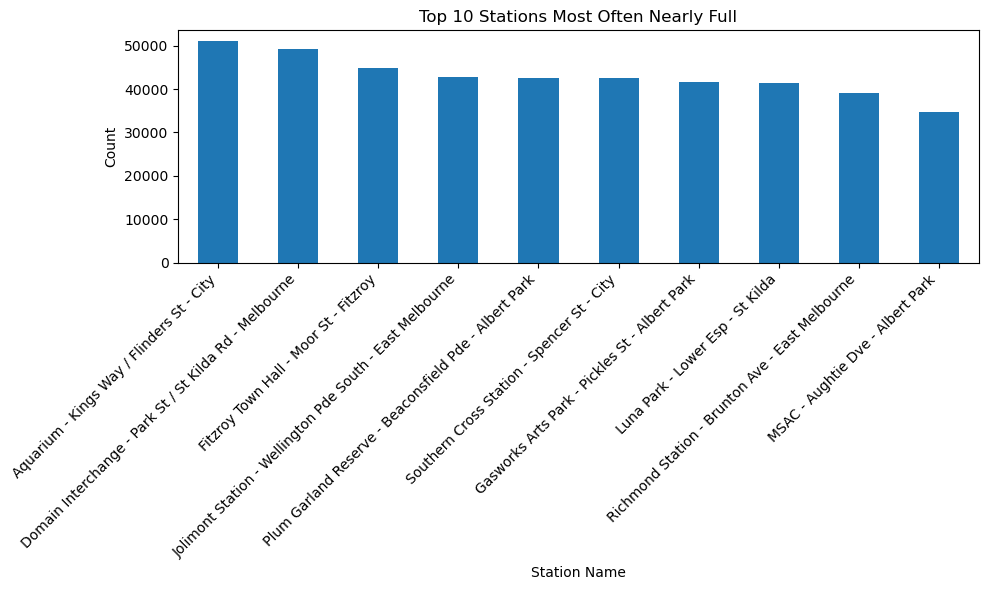

In [35]:
# top 10 stations most nearly full
nearly_full = df[df["pressure_status"] == "Nearly Full"]["NAME"].value_counts().head(10)

plt.figure(figsize=(10, 6))
nearly_full.plot(kind="bar")
plt.title("Top 10 Stations Most Often Nearly Full")
plt.xlabel("Station Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Summary of the findings**

In [37]:
# summary table
print("Top 10 most recorded stations:")
print(df["NAME"].value_counts().head(10))

Top 10 most recorded stations:
NAME
Aquarium - Kings Way / Flinders St - City                  91065
North Melbourne Station - Adderley St - North Melbourne    91065
University Square - Grattan St - Carlton                   91065
Victoria Market - Elizabeth St / Victoria St - City        91065
Flagstaff Gardens - Peel St - West Melbourne               91065
Richmond Station - Brunton Ave - East Melbourne            91064
Argyle Square - Lygon St - Carlton                         91064
Museum - Rathdowne St - Carlton                            91064
ANZ - Collins St - Docklands                               91064
Kings Way / St Kilda Rd - Melbourne                        91064
Name: count, dtype: int64


In [38]:
# summary table
print("Pressure status counts:")
print(df["pressure_status"].value_counts())

Pressure status counts:
pressure_status
Balanced        3896237
Nearly Full     1004760
Nearly Empty     723657
Name: count, dtype: int64


In [39]:
# summary table
print("Average bikes by hour:")
print(df.groupby("hour")["NBBIKES"].mean())

Average bikes by hour:
hour
5    9.334415
Name: NBBIKES, dtype: float64
